In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\quikr_car.csv")
df=data.copy()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [4]:
df=df[df["year"].str.isnumeric()]

In [5]:
df["year"]=df["year"].astype(int)

In [6]:
df=df[df["Price"]!="Ask For Price"]

In [7]:
df["Price"]=df["Price"].str.replace(",","").astype(int)

In [8]:
df["kms_driven"]=df["kms_driven"].str.replace(',','')

In [9]:
df["kms_driven"]=df["kms_driven"].str.replace('kms','')

In [10]:
df=df[df["kms_driven"] !="Petrol"]

In [11]:
df["kms_driven"]=df["kms_driven"].astype(int)

In [12]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel


In [13]:
df.dropna(inplace=True)

In [14]:
df["name"]=df["name"].str.split().str.slice(start=0,stop=3).str.join(" ")

In [15]:
df.shape

(816, 6)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["fuel_type"].value_counts()

fuel_type
Petrol    388
Diesel    330
LPG         2
Name: count, dtype: int64

In [19]:
q1=df["Price"].quantile(0.25)
q3=df["Price"].quantile(0.75)
IQR=q3-q1
min=q1-(IQR*1.5)
max=q3+(IQR*1.5)

In [20]:
df=df[df["Price"]<max]

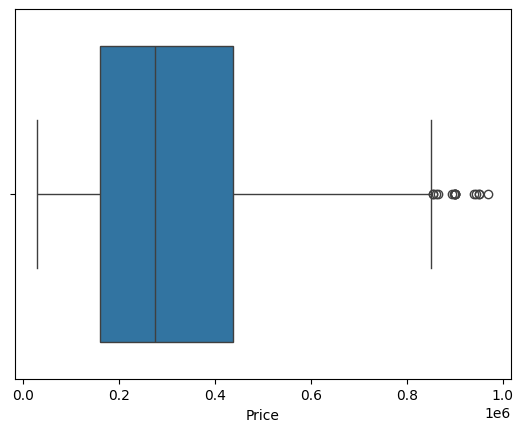

In [21]:
sns.boxplot(x="Price",data=df)
plt.show()

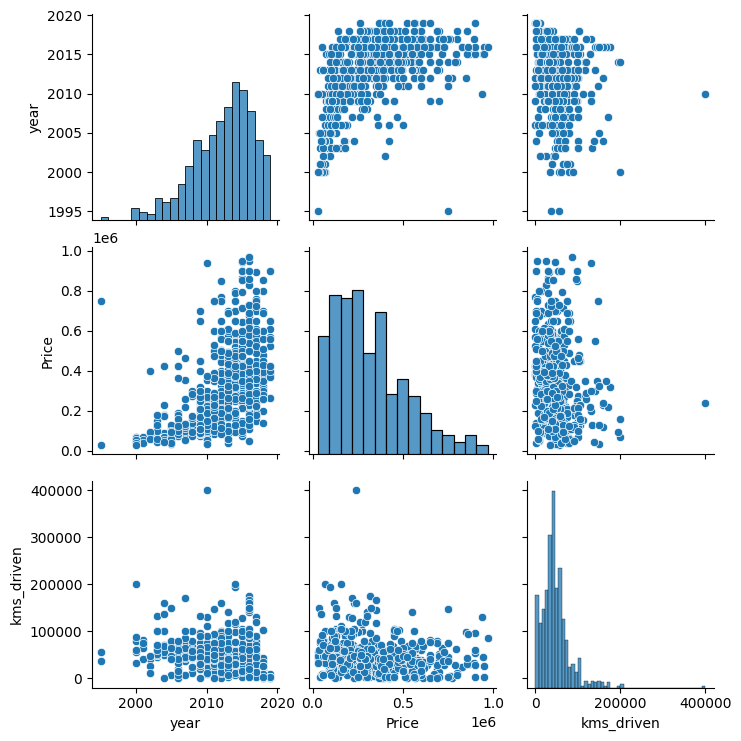

In [22]:
sns.pairplot(data=df)
plt.show()

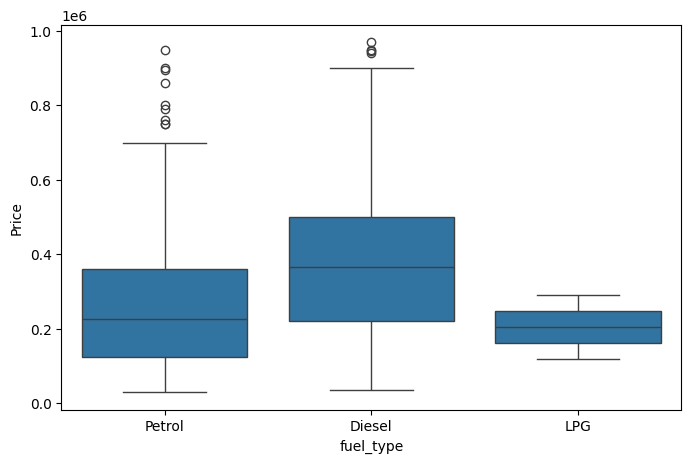

In [23]:
plt.subplots(figsize=(8,5))
sns.boxplot(x="fuel_type",y="Price",data=df)
plt.show()

C:\Users\kumar\AppData\Local\Temp\ipykernel_31440\3034060960.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


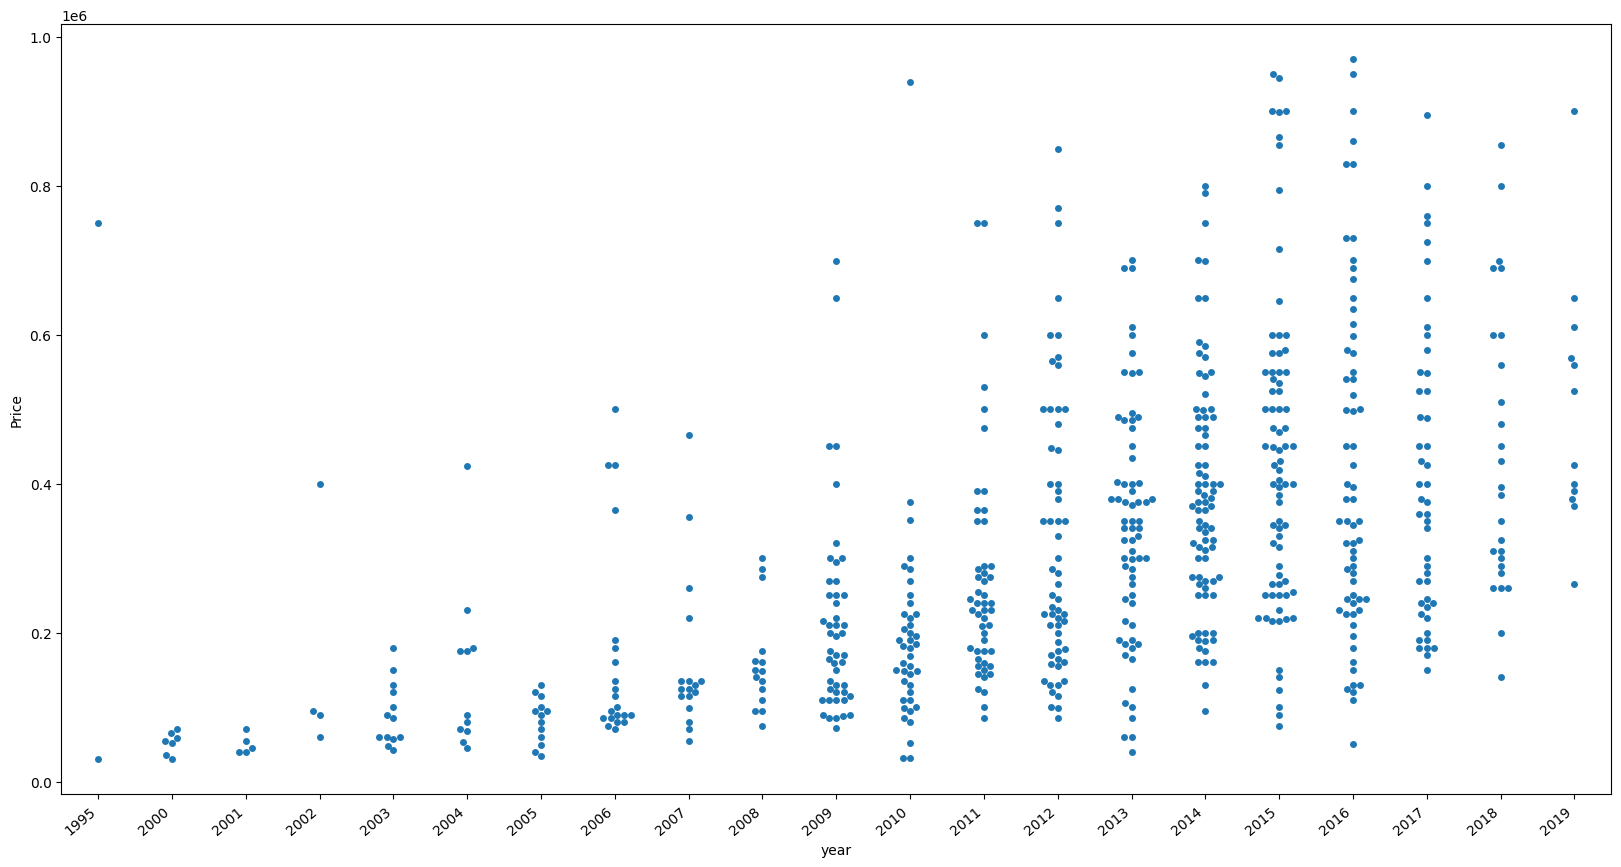

In [24]:
plt.subplots(figsize=(20,10))
ax=sns.swarmplot(x='year',y='Price',data=df)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

C:\Users\kumar\AppData\Local\Temp\ipykernel_31440\475026656.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


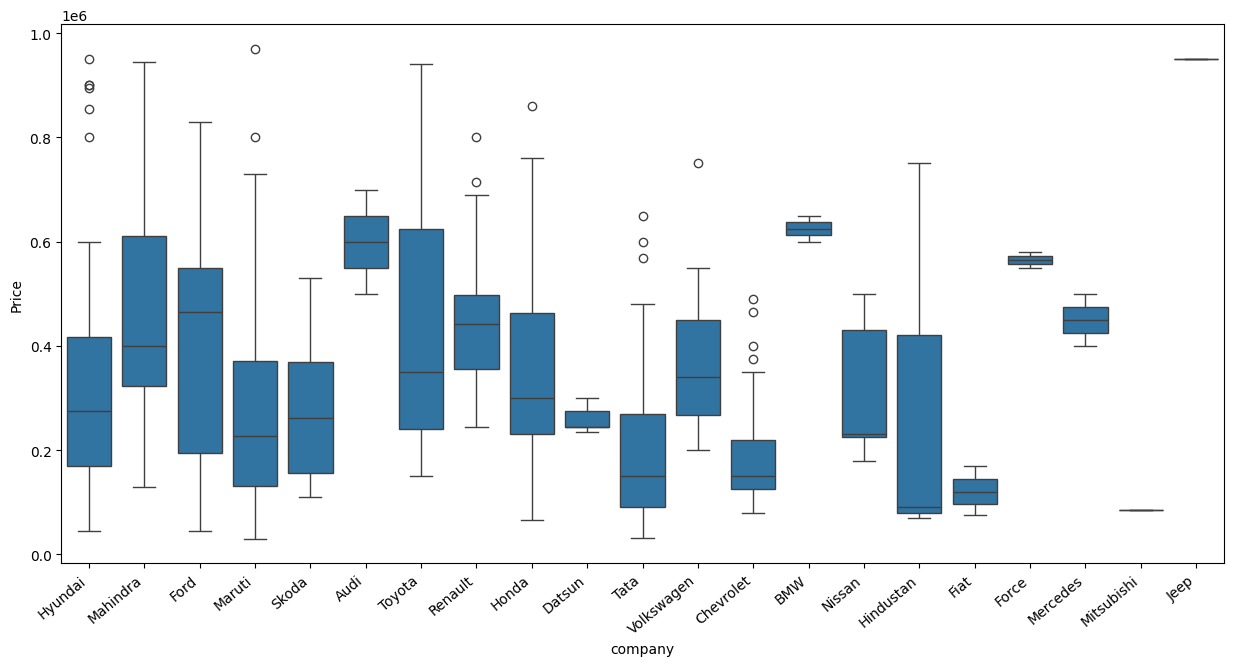

In [25]:
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company',y='Price',data=df)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

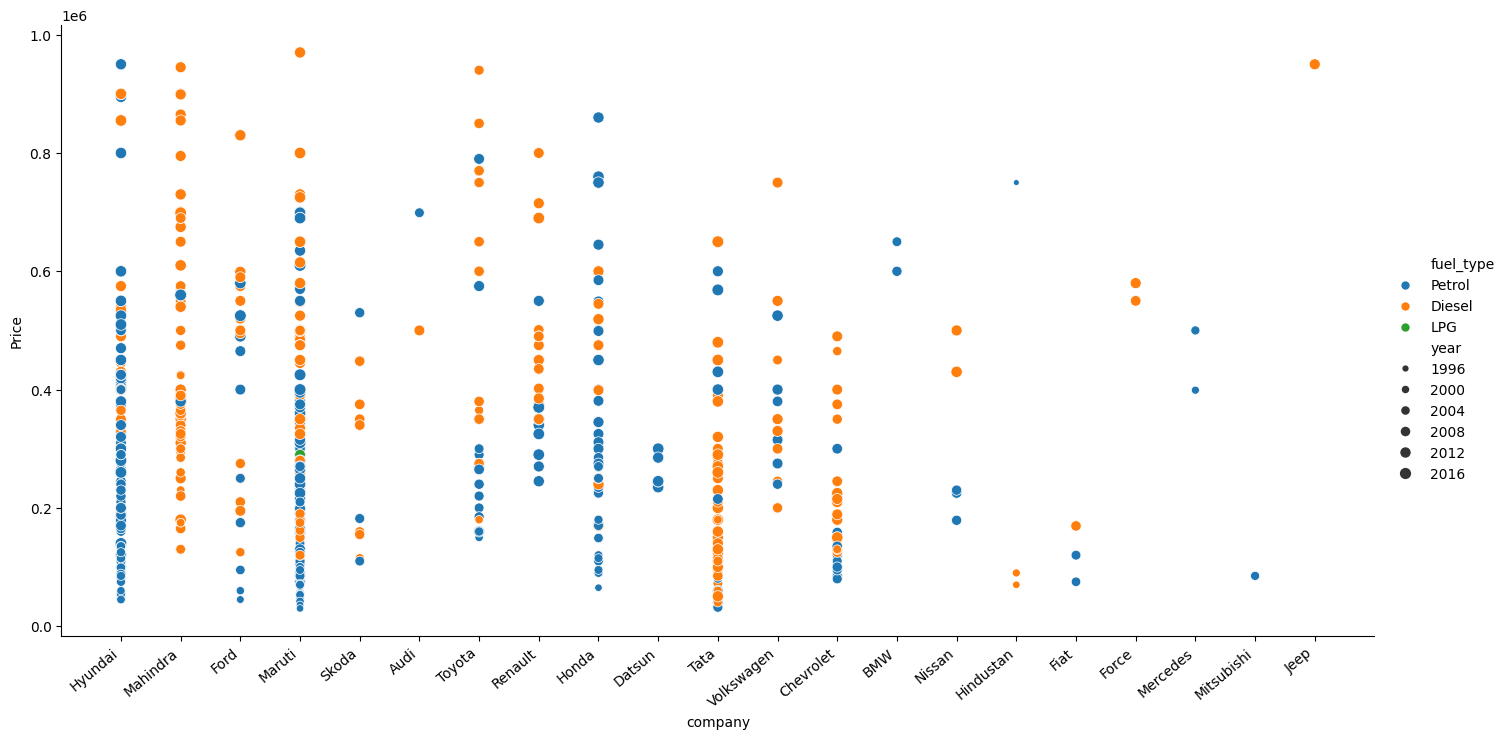

In [26]:
ax=sns.relplot(x='company',y='Price',data=df,hue='fuel_type',size='year',height=7,aspect=2)
ax.set_xticklabels(rotation=40,ha='right')

In [27]:
df.columns

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type'], dtype='object')

In [28]:
x=df[["name","company","year","kms_driven","fuel_type"]]
y=df["Price"]

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2)

In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [31]:
ohe=OneHotEncoder()
ohe.fit(x[['name','company','fuel_type']])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [32]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

In [33]:
lr=LinearRegression()

In [34]:
pipe=make_pipeline(column_trans,lr)

In [35]:
pipe.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred=pipe.predict(x_test)

In [37]:
r2_score(y_test,y_pred)

0.5118085187702365

In [38]:
scores=[]
for i in range(1000):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    scores.append(r2_score(y_test,y_pred))

In [39]:
np.argmax(scores)

np.int64(982)

In [40]:
scores[np.argmax(scores)]

0.8129150812122161

In [41]:
pipe.predict(pd.DataFrame(columns=x_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([416602.84019773])

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)
r2_score(y_test,y_pred)

0.8129150812122161

In [43]:
import pickle

In [44]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [45]:
pipe.predict(pd.DataFrame(columns=['name','company','year','kms_driven','fuel_type'],data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([411407.14689473])

In [46]:
pipe.steps[0][1].transformers[0][1].categories[0]

array(['Audi A4 1.8', 'Audi Q7', 'BMW 3 Series', 'BMW 5 Series',
       'Chevrolet Beat', 'Chevrolet Beat Diesel', 'Chevrolet Beat LS',
       'Chevrolet Beat LT', 'Chevrolet Beat PS', 'Chevrolet Cruze LTZ',
       'Chevrolet Enjoy', 'Chevrolet Enjoy 1.4', 'Chevrolet Sail 1.2',
       'Chevrolet Sail UVA', 'Chevrolet Spark', 'Chevrolet Spark 1.0',
       'Chevrolet Spark LS', 'Chevrolet Spark LT', 'Chevrolet Tavera LS',
       'Chevrolet Tavera Neo', 'Datsun GO T', 'Datsun Go Plus',
       'Datsun Redi GO', 'Fiat Linea Emotion', 'Fiat Petra ELX',
       'Fiat Punto Emotion', 'Force Motors Force', 'Force Motors One',
       'Ford EcoSport', 'Ford EcoSport Ambiente',
       'Ford EcoSport Titanium', 'Ford EcoSport Trend', 'Ford Fiesta',
       'Ford Fiesta SXi', 'Ford Figo', 'Ford Figo Diesel',
       'Ford Figo Duratorq', 'Ford Figo Petrol', 'Ford Fusion 1.4',
       'Ford Ikon 1.3', 'Ford Ikon 1.6', 'Hindustan Motors Ambassador',
       'Honda Accord', 'Honda Amaze', 'Honda Amaze 1.2',

In [47]:
pipe.score(x_test,y_test)

0.8129150812122161